# 프로젝트1 당뇨병 수치 맞추기

In [1]:
# sklearn.datasets의 load_diabetes에서 데이터를 가져와주세요.
# diabetes의 data를 df_X에, target을 df_y에 저장해주세요.

from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [2]:
# df_X에 있는 값들을 numpy array로 변환해서 저장

import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [3]:
# df_y에 있는 값들을 numpy array로 변환해서 저장

y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [4]:
# X와 y 데이터를 각각 train 데이터와 test 데이터로 분리

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [5]:
# 입력 데이터 개수에 맞는 가중치 W와 b를 준비
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [6]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [7]:
# 손실함수를 MSE 함수로 정의

def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [8]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [9]:
# 기울기를 계산하는 gradient 함수

def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [10]:
# 학습률, learning rate 를 설정

LEARNING_RATE = 0.06

In [11]:
# 정의된 손실함수와 기울기 함수로 모델을 학습

In [12]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 2001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5624.1729
Iteration 200 : Loss 5263.7806
Iteration 300 : Loss 4963.7345
Iteration 400 : Loss 4712.8828
Iteration 500 : Loss 4502.2065
Iteration 600 : Loss 4324.4067
Iteration 700 : Loss 4173.5725
Iteration 800 : Loss 4044.9125
Iteration 900 : Loss 3934.5395
Iteration 1000 : Loss 3839.2960
Iteration 1100 : Loss 3756.6142
Iteration 1200 : Loss 3684.4028
Iteration 1300 : Loss 3620.9554
Iteration 1400 : Loss 3564.8775
Iteration 1500 : Loss 3515.0269
Iteration 1600 : Loss 3470.4658
Iteration 1700 : Loss 3430.4222
Iteration 1800 : Loss 3394.2586
Iteration 1900 : Loss 3361.4468
Iteration 2000 : Loss 3331.5479
260 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [13]:
# test 데이터에 대한 성능을 확인
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(3023.4816327722765)

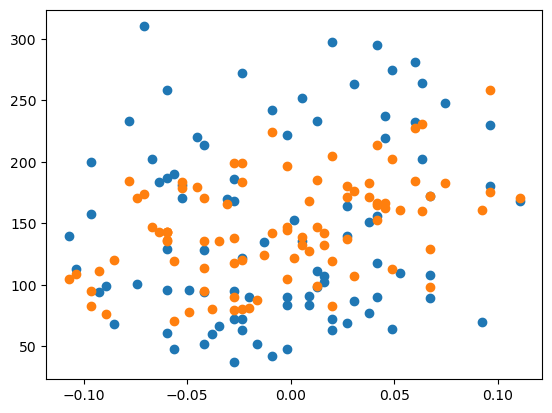

In [14]:
# x축에는 X 데이터의 첫 번째 컬럼을, y축에는 정답인 target 데이터를 넣어서 모델이 예측한 데이터를 시각화

import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

# 프로젝트2 자전거 타는 사람은 몇 명?

In [15]:
# 데이터 가져오기
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [16]:
# datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기

train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

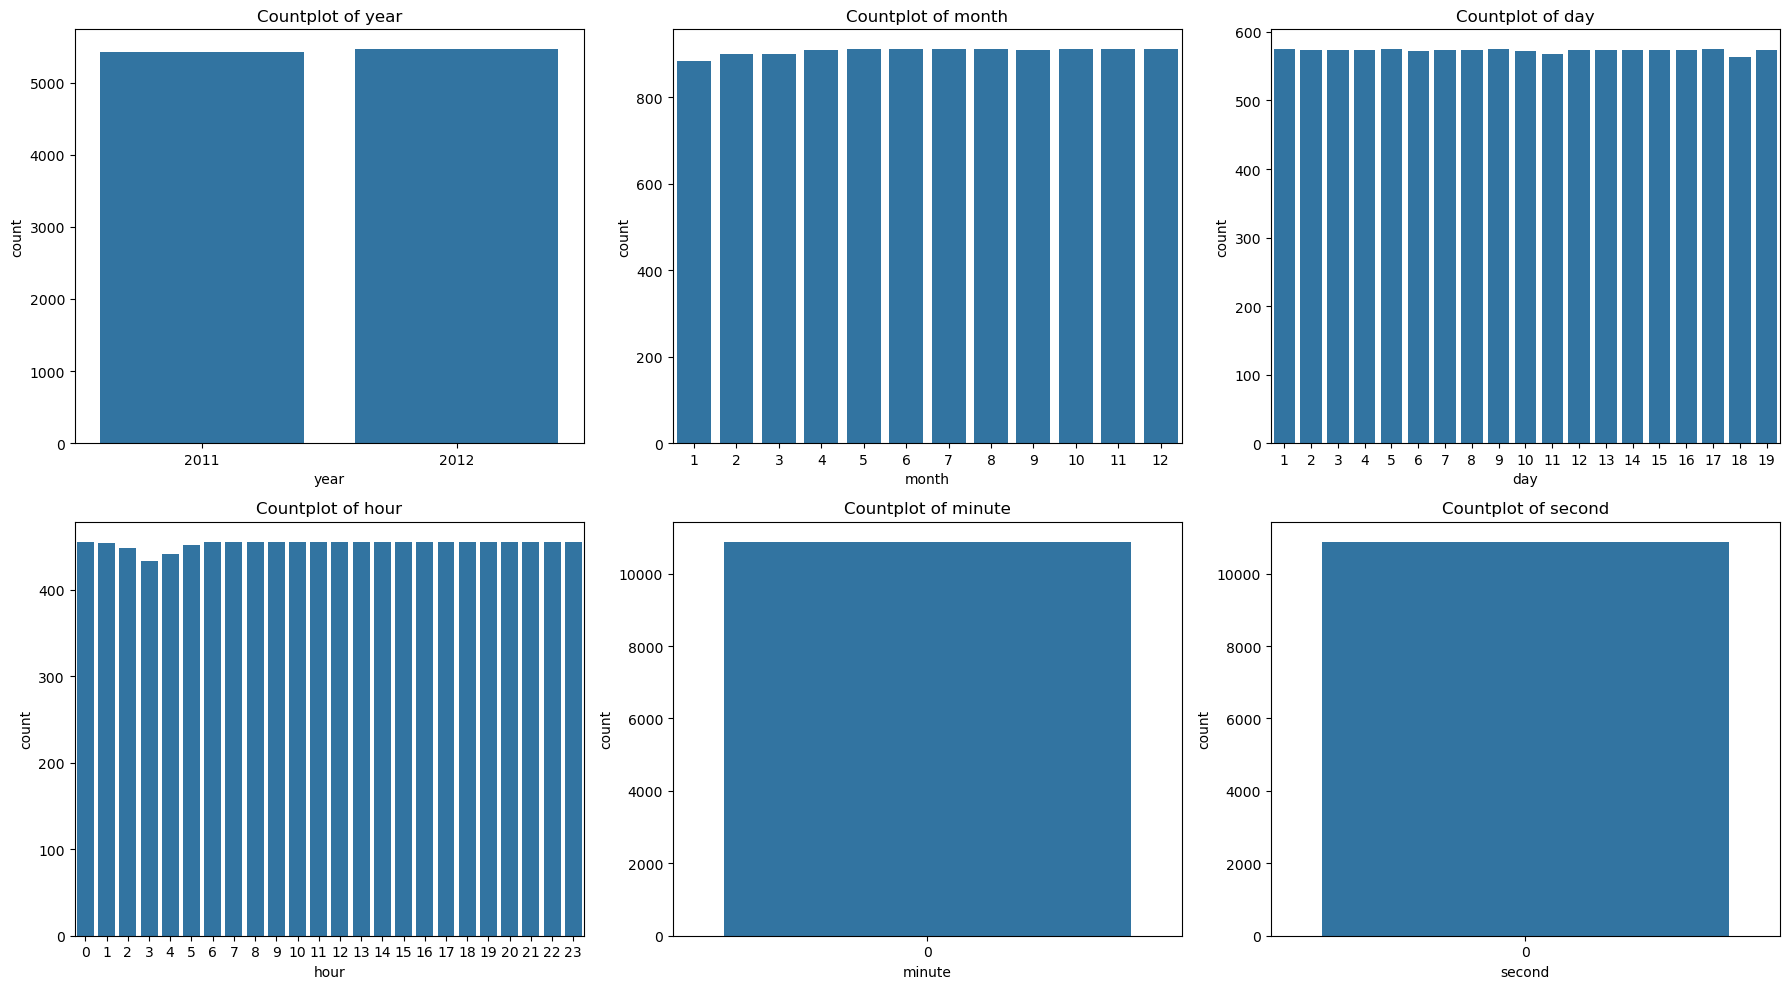

In [17]:
# year, month, day, hour, minute, second 데이터 개수 시각화하기

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [18]:
# X, y 컬럼 선택 및 train/test 데이터 분리

# 자전거 타는 명수가 필요하니, Y에 count 데이터 넣기

features = ['year', 'month', 'hour', 'temp', 'humidity', 'windspeed', 'holiday', 'workingday']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# ----------------------------------------------------
# (추가해야 할 부분) 모델 불러오고 공부시키기!
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
# ----------------------------------------------------

# (원래 있던 코드) 공부한 내용으로 시험 보기

# 학습된 모델에 X_test를 입력해서 예측값 출력하기
# 모델이 예측한 값과 정답 target 간의 손실함수 값 계산하기
# mse 값과 함께 rmse 값도 계산하기

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19980.122769868194
RMSE: 141.3510621462329


In [23]:

from sklearn.preprocessing import StandardScaler

# 1. 스케일러(정규화 도구) 준비
scaler = StandardScaler()

# 2. X_train 데이터의 기준을 찾고(fit) 그 기준에 맞춰 변환(transform)
X_train_scaled = scaler.fit_transform(X_train)

# 3. X_test 데이터는 X_train의 기준에 맞춰서 변환(transform)만!
X_test_scaled = scaler.transform(X_test)

# 4. 정규화된 데이터로 모델 학습하기
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. 정규화된 데이터로 예측하기
y_pred = model.predict(X_test_scaled)

# (이후 MSE, RMSE 계산 코드는 동일합니다)



# sklearn의 LinearRegression 모델 불러오기 및 학습하기

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
print(X, y)

In [ ]:
#  x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기
# '날씨가 좋은' 이니 temp나 humidity 데이터를 넣어 시각화하기

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()